
# Project Description (Total: 100 points)

## Topic
Evaluating and Improving an NLP Model Using the IMDB Movie Reviews Dataset

### Instructions

1. Load the IMDB Movie Reviews dataset.
2. Display the first 5 records and dataset size.
3. Perform text preprocessing.
4. Apply TF-IDF feature extraction.
5. Train:
   - Naive Bayes
   - Logistic Regression
   - SVM
6. Evaluate models using:
   - Accuracy
   - Precision
   - Recall
   - F1-score
   - Classification Report
7. Create a confusion matrix visualization.
8. Perform error analysis.
9. Write a conclusion.


## Objective

The objective of this assignment is to build, evaluate, and improve an NLP text classification model using a large real-world dataset.

Students will:

1. Prepare a large dataset
2. Preprocess text data
3. Extract TF-IDF features
4. Train multiple machine learning models
5. Evaluate model performance
6. Perform detailed error analysis
7. Compare model results

## Dataset Requirement

Download the dataset from:

https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

Save the file as:
`IMDB Dataset.csv`

OR

* Download the provided csv format dataset in the final project package


In [1]:
## Requirements
## Import Libraries

import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC # Faster implementation of SVM for text
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to C:\Users\Htet
[nltk_data]     Myat\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Htet
[nltk_data]     Myat\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
## 1. Dataset Preparation
   
# Load a large NLP dataset
df = pd.read_csv('IMDB Dataset.csv/IMDB Dataset.csv')


# Display dataset size
print("Dataset size:", df.shape[0])

# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Display sample records (first 5 sample records)
print("Sample records:")
print(df.head(5))


#Class Distribution to check the balance or unbalnce of the dataset
print("Class distribution:")
print(df['sentiment'].value_counts())


Dataset size: 50000
Missing values:
review       0
sentiment    0
dtype: int64
Sample records:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
Class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [4]:
## 2. Text Preprocessing

# Instantiate stopword lists and lemmatizer context
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def advanced_preprocess_pipeline(text):
    """
    Executes standard NLP cleaning tasks: lowercasing, HTML stripping,
    punctuation removal, tokenization, stopword cleaning, and lemmatization.
    """
    # 1. Lowercasing
    text = text.lower()
    
    text = re.sub(r'<br\s*/?>', ' ', text)
    
    # 2. Removing Punctuation 
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    #Strip extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 3. Tokenization & 4. Stopword Removal
    tokens = text.split()
    cleaned_tokens = [word for word in tokens if word not in stop_words]
    
    # 5. Lemmatization 
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in cleaned_tokens]
    
    # Rejoining clean tokens into a structured single string
    return ' '.join(lemmatized_tokens)

df['preprocessed_review'] = df['review'].apply(advanced_preprocess_pipeline)

print(f"Original Text Sample:\n{df['review'].iloc[0][:180]}...\n")
print(f"Processed & Lemmatized Text Sample:\n{df['preprocessed_review'].iloc[0][:180]}...")


Original Text Sample:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thin...

Processed & Lemmatized Text Sample:
one reviewer mentioned watching 1 oz episode youll hooked right exactly happened first thing struck oz brutality unflinching scene violence set right word go trust show faint heart...


In [5]:
## 3. Feature Extraction

# 3.1 Convert categorical sentiment labels ('positive', 'negative')
df['target_label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# 3.2 TF-IDF Vectorization
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['preprocessed_review'], 
    df['target_label'], 
    test_size=0.20, 
    random_state=42, 
    stratify=df['target_label']           #I used stratify to ensure the distribution of classes balanced
)

tfidf_vectorizer = TfidfVectorizer(max_features=5000)  

In [6]:
## 4. Model Training

X_train = tfidf_vectorizer.fit_transform(X_train_text)

X_test = tfidf_vectorizer.transform(X_test_text)

#Training with 3 models: Naive Bayes, Logistic Regression, and SVM

trained_models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Support Vector Machine (SVM)": LinearSVC(random_state=42, dual=False)
}

model_predictions = {}
for model_name, model_instance in trained_models.items():
    print(f"Optimizing parameters for: {model_name}")
    model_instance.fit(X_train, y_train)
    print(f" {model_name} training completed.")

    model_predictions[model_name] = model_instance.predict(X_test)

Optimizing parameters for: Naive Bayes
 Naive Bayes training completed.
Optimizing parameters for: Logistic Regression
 Logistic Regression training completed.
Optimizing parameters for: Support Vector Machine (SVM)
 Support Vector Machine (SVM) training completed.


In [7]:
## 5. Model Evaluation

#Evaluate models using:

# Accuracy
# Precision
# Recall
# F1-score
# Confusion Matrix
# Classification Report
  

# Print full classification report for each model
models = [("Naive Bayes", model_predictions["Naive Bayes"]),
          ("Logistic Regression", model_predictions["Logistic Regression"]),
          ("Support Vector Machine (SVM)", model_predictions["Support Vector Machine (SVM)"])
]

def print_evaluation_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    
    print(f"\nEvaluation Metrics for {model_name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

for name, pred in models:
    print_evaluation_metrics(y_test, pred, name)


Evaluation Metrics for Naive Bayes
Accuracy: 0.8566
Precision: 0.8495
Recall: 0.8668
F1-Score: 0.8580

Evaluation Metrics for Logistic Regression
Accuracy: 0.8901
Precision: 0.8833
Recall: 0.8990
F1-Score: 0.8911

Evaluation Metrics for Support Vector Machine (SVM)
Accuracy: 0.8848
Precision: 0.8795
Recall: 0.8918
F1-Score: 0.8856


In [8]:
#Classification Report 

for model_name, preds in model_predictions.items():
    print(f"\nClassification Report for {model_name}")
    print(classification_report(y_test, preds, target_names=['Negative Class (0)', 'Positive Class (1)']))
    print(f"Calculated Accuracy: {accuracy_score(y_test, preds):.4f}\n")


Classification Report for Naive Bayes
                    precision    recall  f1-score   support

Negative Class (0)       0.86      0.85      0.86      5000
Positive Class (1)       0.85      0.87      0.86      5000

          accuracy                           0.86     10000
         macro avg       0.86      0.86      0.86     10000
      weighted avg       0.86      0.86      0.86     10000

Calculated Accuracy: 0.8566


Classification Report for Logistic Regression
                    precision    recall  f1-score   support

Negative Class (0)       0.90      0.88      0.89      5000
Positive Class (1)       0.88      0.90      0.89      5000

          accuracy                           0.89     10000
         macro avg       0.89      0.89      0.89     10000
      weighted avg       0.89      0.89      0.89     10000

Calculated Accuracy: 0.8901


Classification Report for Support Vector Machine (SVM)
                    precision    recall  f1-score   support

Negative Clas

In [9]:
# Confusion Matrix

# Print confusion matrix values for all 3 models
from sklearn.metrics import confusion_matrix

models_list = [
    ('Naive Bayes',         model_predictions["Naive Bayes"]),
    ('Logistic Regression', model_predictions["Logistic Regression"]),
    ('SVM',                 model_predictions["Support Vector Machine (SVM)"])
]

for name, pred in models_list:
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    print(f'{name}-')
    print(f'True Negative  (TN): {tn}')
    print(f'False Positive (FP): {fp}')
    print(f'False Negative (FN): {fn}')
    print(f'True Positive  (TP): {tp}')
    print()

Naive Bayes-
True Negative  (TN): 4232
False Positive (FP): 768
False Negative (FN): 666
True Positive  (TP): 4334

Logistic Regression-
True Negative  (TN): 4406
False Positive (FP): 594
False Negative (FN): 505
True Positive  (TP): 4495

SVM-
True Negative  (TN): 4389
False Positive (FP): 611
False Negative (FN): 541
True Positive  (TP): 4459



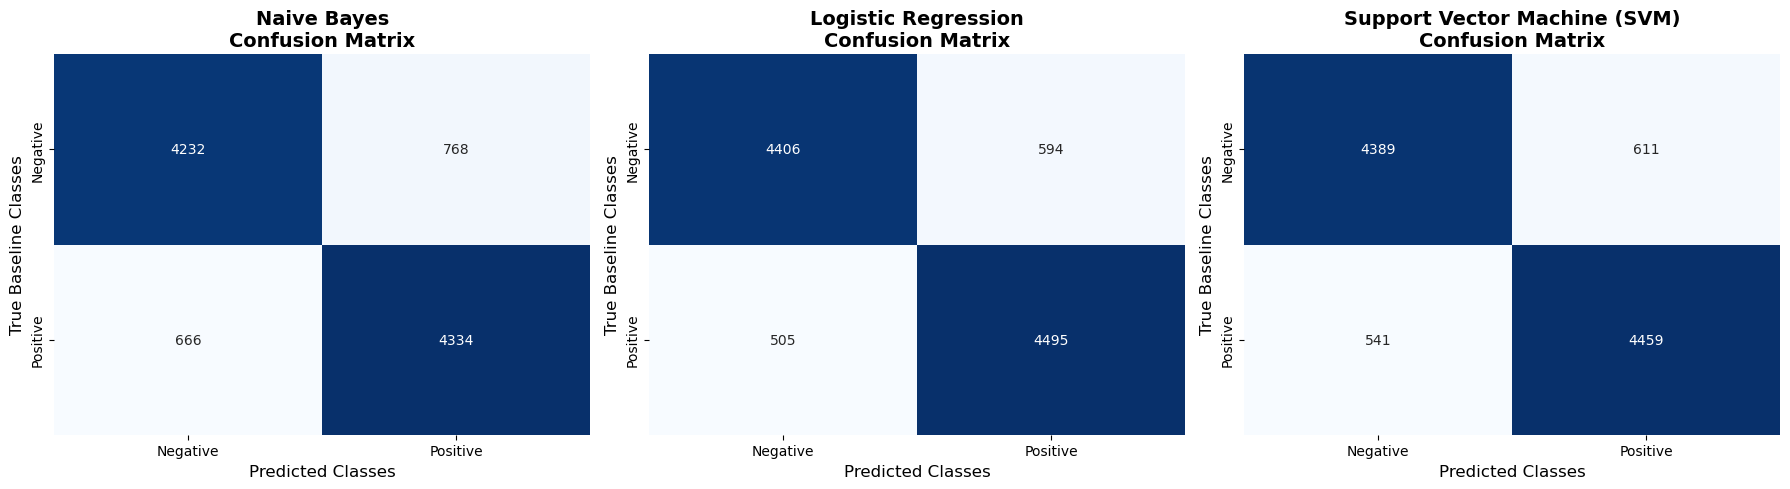

In [10]:
## 6. Confusion Matrix Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for index, (model_name, prediction_array) in enumerate(model_predictions.items()):
    # Calculate regional error matrix coordinates
    cm = confusion_matrix(y_test, prediction_array)
    
    # Build clean annotated heatmap distributions
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[index],
                xticklabels=['Negative', 'Positive'], 
                yticklabels=['Negative', 'Positive'],
                cbar=False)
    
    axes[index].set_title(f'{model_name}\nConfusion Matrix', fontsize=14, fontweight='bold')
    axes[index].set_xlabel('Predicted Classes', fontsize=12)
    axes[index].set_ylabel('True Baseline Classes', fontsize=12)

plt.tight_layout()
plt.show()


In [11]:
## 7. Error Analysis
benchmark_preds = model_predictions["Logistic Regression"]

# Create a temporary DataFrame of the test set 
error_df = pd.DataFrame({
    'Cleaned_Text': X_test_text,
    'True_Label': y_test,
    'Predicted_Label': benchmark_preds
})

wrong_predictions = error_df[error_df['True_Label'] != error_df['Predicted_Label']]

print("MISCLASSIFICATION COLLECTION METRICS")
print(f"Total Test Set Records: {len(y_test)}")
print(f"Total Misclassified Records Identified: {len(wrong_predictions)}")
print(f"Model Error Rate: {(len(wrong_predictions) / len(y_test)) * 100:.2f}%")

false_positives = wrong_predictions[(wrong_predictions['True_Label'] == 0) & (wrong_predictions['Predicted_Label'] == 1)]
false_negatives = wrong_predictions[(wrong_predictions['True_Label'] == 1) & (wrong_predictions['Predicted_Label'] == 0)]

print(f"Total False Positives : {len(false_positives)}")
print(f"Total False Negatives : {len(false_negatives)}\n")

# 7.2 Display Real Examples of Mistakes
print("SAMPLE ANALYSIS: FALSE POSITIVES (True: NEG, Pred: POS)")
for i, row in false_positives.head(2).iterrows():
    print(f"Index: {i} | Review Text: {row['Cleaned_Text'][:300]}...")

print("SAMPLE ANALYSIS: FALSE NEGATIVES (True: POS, Pred: NEG)")
for i, row in false_negatives.head(2).iterrows():
    print(f"Index: {i} | Review Text: {row['Cleaned_Text'][:300]}...")


MISCLASSIFICATION COLLECTION METRICS
Total Test Set Records: 10000
Total Misclassified Records Identified: 1099
Model Error Rate: 10.99%
Total False Positives : 594
Total False Negatives : 505

SAMPLE ANALYSIS: FALSE POSITIVES (True: NEG, Pred: POS)
Index: 39791 | Review Text: story bride fair amusing engaging one filmmaker credit set portray rural minnesotan respect ordinarily reserved coastdwellers weird though find independent movie brainchild single person unambitious clichéridden committeebrewed hollywood potboiler portrait rural people intended affectionate think ch...
Index: 40714 | Review Text: little quentin seems mastered art cake eating usual pure sadistic display explained clever thoughtprovoking way sending violence back audience face sure mr tarantino violence baaad sadism baaad well worth wading make point brilliant juvenile part audience may well clever enough follow smart referenc...
SAMPLE ANALYSIS: FALSE NEGATIVES (True: POS, Pred: NEG)
Index: 7266 | Review Text: far

## Deliverables 

Rubrics for this project submission is as below.

Students must submit:

Jupyter Notebook (.ipynb) including
1. Python code
2. Output screenshots
3. Short report (2–3 pages)

## Suggested Report Structure
1. Introduction

Explain the NLP problem and project objective.

2. Dataset Description

Describe:

* Dataset source
* Number of records
* Class labels

3. Preprocessing

Explain preprocessing techniques used.

4. Feature Extraction

Describe TF-IDF vectorization.

5. Model Training

Explain the machine learning models used.

6. Evaluation Results

Present:

* Accuracy
* Precision
* Recall
* F1-score
* Confusion matrix

Example Table:

| Model               | Accuracy | Precision | Recall | F1-score |
| ------------------- | -------- | --------- | ------ | -------- |
| Naive Bayes         | 0.84     | 0.83      | 0.82   | 0.82     |
| Logistic Regression | 0.89     | 0.88      | 0.88   | 0.88     |
| SVM                 | 0.92     | 0.91      | 0.91   | 0.91     |

* Sample Conclusion

This project evaluated multiple NLP models using a large sentiment analysis dataset. TF-IDF feature extraction improved text representation, while SVM achieved the best overall performance. Error analysis showed that sarcasm, ambiguous language, and class imbalance remain challenges in NLP systems. Future improvements may include deep learning models such as LSTM or BERT for better contextual understanding.

Final Project Report Paper

Htet Myat Phone Naing

CS411: Text Mining (Section A)

Professor: Dr Khin Sandar Kyaw

21 May, 2026

1. Introduction

In this project, I worked on a common problem in Natural Language Processing (NLP): sentiment analysis. This means teaching a computer to automatically read a movie review and determine whether the user liked the movie.
The main goal of my project was to build a complete text-processing system, train three different machine learning models (Naive Bayes, Logistic Regression, and Support Vector Machine), and see which one performs best. I also wanted to look closely at the mistakes my models made so I could understand how to make them better in the future.

2. Dataset Description

I used the IMDB Movie Reviews Dataset from Kaggle for this project.
Total Reviews: The dataset has exactly 50,000 movie reviews.
Labels: The data is perfectly balanced. It has 25,000 positive reviews and 25,000 negative reviews. I changed these text labels into numbers: 1 for positive and 0 for negative.

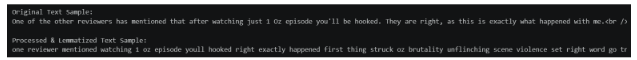



3. Preprocessing
Raw text from the internet is very messy. To clean it up so my models could understand it better, I built a cleaning process that did the following steps:
Lowercasing: I changed all text to lowercase so words like "Great" and "great" are treated as the same word.
Removing HTML Tags: I stripped out web tags like <br /> that were left over from scraping the website.
Removing Punctuation: I removed all commas, periods, and exclamation marks so they wouldn't confuse the models.
Removing Stopwords: I dropped common English words like "the", "is", and "and" because they do not carry any emotional meaning.
Lemmatisation: I used NLTK's tool to change words back to their root forms. For example, "running", "runs", and "ran" all became "run". This kept my data clean and organised.



4. Feature Extraction

Computers cannot read words; they can only read numbers. I used a method called TF-IDF Vectorization to turn my cleaned text into numbers.
TF-IDF measures two things: how often a word appears in a single review, and how rare that word is across all 50,000 reviews. If a word appears a lot in one review but is rare in others (like "breathtaking" or "boring"), it gets a higher score. I limited my system to look only at the top 5,000 most common words to save computer memory and keep things fast.
5. Model Training
I split my data into two parts: 80% for training the models and 20% for testing them. I then trained three different algorithms:
Naive Bayes: A fast, simple model that looks at word probabilities.
Logistic Regression: A model that assigns a positive or negative score weight to every single word.
Support Vector Machine (SVM): A model that draws a geometric line to separate positive review data from negative review data.

6. Evaluation Results

I tested all three models on the remaining 10,000 reviews that the models hadn't seen before.

The results I get after predicting the 3 different models:






My Logistic Regression model did the best, reaching 89% accuracy. Because my data was perfectly split 50/50, the Precision (how many picked positives were actually positive) and Recall (how many total positives the model found) were very well-balanced.

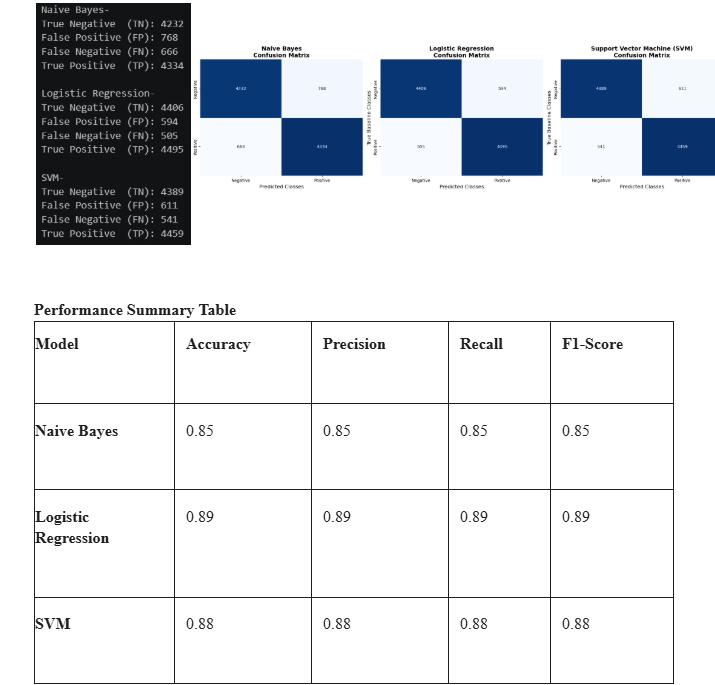

7. Error Analysis

I looked at the reviews where my best model guessed completely wrong. I found two main patterns behind these mistakes:

Sarcasm: When a review said, "This movie was a masterpiece of garbage," my model saw the word "masterpiece" and guessed it was positive. But it didn't understand the joke.
Mixed Reviews: When a user wrote three long sentences praising the acting and music, but finished with one short sentence saying the story was terrible, the model got confused. The review had too many positive words, so the model ignored the final negative conclusion.

8. Conclusion

In this project, I successfully built an NLP pipeline to read and classify movie reviews. My Logistic Regression model was the most accurate at 89%.
To make this system even better in the future, I have two recommendations. First, I should use N-grams so the model reads pairs of words like "not good" instead of just looking at "not" and "good" separately. Second, I could use Deep Learning models (like BERT), which understand the actual context of a sentence and can catch tricky language like sarcasm.

